## 유방암 데이터셋 
#### 유방암 예측 모델 : 양성 여부 판단
- 0: 음성(정상) / 1: 양성(암)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer


In [2]:
# 데이터 불러오기

cancer = load_breast_cancer()
# cancer.keys() # 필요한 값 담긴 key 확인 -> data, target, feature_names

df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# target(y) 의미 파악 (0,1 중에 어떤게 양성을 의미하는지)
print(cancer.target_names)

'''
결과: ['malignant', 'benign'] -> 보통 target_names의 인덱스와 target 대응
원본:
    0 = malignant = 악성 종양 = 암
    1 = benign = 양성 종양 = 정상

수정 필요: 
    의료 데이터에는 암(양성)을 찾아내는게 목표.
    보통 찾고자 하는 값이 positive, 혼동행렬이나 평가 지표에서도 1을 positive로 봄 
    그런데 원본 데이터는 1이 음성(정상)인 상태.
    즉, 원하는 TP(실제 양성인데 양성으로 예측)의 의미로 확인하기 위해서는 라벨을 바꿔야 보기 편함 

    
# 나중에 recall_score(y_test, y_pred, pos_label=0)처럼 옵션으로 조정할 수도 있지만 헷갈림
'''

# 수정 전 원본 target 개수 확인
np.unique(cancer.target,return_counts=True)

# 양성(암) = 0 -> 212개
# 음성(정상) = 1 -> 357개

['malignant' 'benign']


(array([0, 1]), array([212, 357]))

In [4]:
# 내가 쓸 target으로 수정
# 0 = 음성(정상), 1 = 양성(암)
df["label"] = np.where(cancer.target == 0, 1, 0)

In [5]:
# 수정 후 확인 : 0(음성 357개), 1(양성 212개)
df['label'].value_counts()

label
0    357
1    212
Name: count, dtype: int64

In [6]:
# 컬럼 의미 살펴보기 
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'label'],
      dtype='str')

- radius: 세포핵 중심에서 경계까지 거리의 평균(반지름)
- texture: 회색조 값의 표준편차, 질감의 변화 정도
- perimeter: 세포핵 둘레
- area: 세포핵 면적
- smoothness: 반지름 길이의 국소적 변화 정도
- compactness: perimeter^2 / area - 1.0, 조밀도
- concavity: 윤곽의 오목한 부분 정도
- concave points: 오목한 부분의 점 개수 또는 정도
- symmetry: 대칭성
- fractal dimension: 경계 복잡도, 프랙탈 차원

In [7]:
# 데이터 탐색

df.shape  #feature 30개, 종속변수 1개
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


- 대부분 크기, 둘레 같은 측정값 
- 연속형 수치 데이터 
- 컬럼별 단위 차이 큼
- 거리 기반 모델(서로 비슷한 샘플은 가까이 있을 것이라는 가정)
    - 스케일링 중요
    - 숫자의 차이를 거리로 계산
    - 평균 기준 상대적 크기 의미 있음(standardscaler)


In [8]:
# 결측치 확인
df.isnull().sum()

# 중복값 확인
df.duplicated().sum()


np.int64(0)

In [9]:
# 데이터 전처리

X = df.drop(['label'],axis=1)
y = df['label']

In [10]:
# 스케일링

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [11]:
# 데이터 분할
# 분할시에도 y의 클래스 비율 비슷하게 유지 

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(scaled_X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

In [12]:
# 학습
# 여러 모델 비교 (score: 예측 후 정답과 비교해서 점수(정확도)만 확인)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

tree_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
svc_model = SVC(random_state=42)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
lr_model = LogisticRegression(random_state=42)

model_list = [tree_model,knn_model,svc_model,rf_model,lr_model]

for model in model_list:
    model.fit(X_train,y_train)
    score = model.score(X_test,y_test)
    print(f'{model.__class__.__name__} 정확도: {round(score,4)}')



DecisionTreeClassifier 정확도: 0.9298
KNeighborsClassifier 정확도: 0.9561
SVC 정확도: 0.9737
RandomForestClassifier 정확도: 0.9737
LogisticRegression 정확도: 0.9649


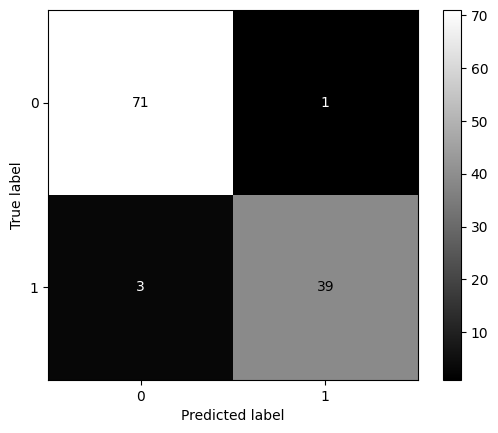

In [13]:
# LogisticRegression 모델 자세히 확인

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 예측 
y_pred = lr_model.predict(X_test)

# 혼돈 행렬 시각화 
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot(cmap='gray')

- 114건의 테스트 데이터 중 110건 정답
- 오답: 양성을 음성으로 예측 3건, 음성을 양성으로 예측 1건 

In [18]:
# 평가 지표 확인
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 분류 모델 평가지표 확인
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'정확도: {acc:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, f1: {f1:.4f}')

# 분류 모델 주요 성능 지표 한 번에 보기 
# 위와 동일하게 소수점 4자리까지 확인-> digits 옵션 적용 
print(classification_report(y_test, y_pred, target_names=["음성(정상)", "양성(암)"],digits=4))

정확도: 0.9649, 정밀도: 0.9750, 재현율: 0.9286, f1: 0.9512
              precision    recall  f1-score   support

      음성(정상)     0.9595    0.9861    0.9726        72
       양성(암)     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



### 유방암 예측에서 중요도가 높은 평가 지표는?

>- TP: 실제 양성을 양성이라고 맞춘 경우
>- TN: 실제 음성을 음성이라고 맞춘 경우
>- FP: 실제 음성인데 양성라고 잘못 예측한 경우
>- FN: 실제 양성인데 음성이라고 잘못 예측한 경우


- 정확도: 전체적인 정답율
    - accuracy = (TP + TN) / (TP + TN + FP + FN)
    - 직관적이나 클래스 불균형시 착시 존재 
&nbsp;
- 정밀도: 양성이라고 **예측**한 것 중에서 실제로 양성인 비율
    - Precision = TP / (TP + FP)
    - 정밀도가 낮으면 음성 환자의 불필요한 추가 검사나 불안도 늘어남 
&nbsp;
- 재현율: **실제 양성** 중에서 양성을 얼마나 잘찾아냈는가(양성 정답율)
    - Recall = TP / (TP + FN)
    - 재현율이 낮으면 양성 환자를 놓치는 경우가 많은 것(위험) -> **매우 중요**
&nbsp;
- F1-score: 정밀도와 재현율의 조화평균
    - F1 = 2 * (Precision * Recall) / (Precision + Recall)
    - 정밀도와 재현율을 균형 있게 잘 봤을 때 점수가 높음

---

### 다음 목표: 양성(암)을 놓치지 않는 모델 찾기 
- 모델 선택 기준 바꾸기 
    - 재현율이 가장 중요하기 때문
    - 양성 recall 높은 모델 확인 
- 하이퍼 파라미터 튜닝
    - GridSearch: 정해 둔 후보 전부 탐색 
    - threshold 조정: 이진 분류에서 중요(기본적으로는 확률이 0.5 이상이면 양성으로 분류)
    - class_weight 조정

- 추천 스템
1. 스케일링 순서 수정
2. 여러 모델을 accuracy가 아니라 recall 중심으로 다시 비교
3. recall이 높은 모델 2~3개를 classification_report + confusion matrix로 자세히 보기
4. 그중 후보 모델에 GridSearchCV 또는 RandomizedSearchCV 적용
5. 필요하면 threshold 조정으로 FN 줄이기